# Diagnose: Why Do Fundamental Data Add No Value?

This notebook is a **separate diagnosis**, not post-hoc model optimization. It loads the stored results from `eval/comparison.json` and `eval/comparison_ledgers.csv` and checks several possible explanations for the observed `market` versus `full` difference.

The analysis covers data quality, temporal alignment, information content, simple references, time-period limitations, trading costs, feature ablations, and statistical uncertainty. The results are indications, not causal proof.

In [9]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "eval").exists():
    ROOT = ROOT.parent
with (ROOT / "eval" / "comparison.json").open(encoding="utf-8") as handle:
    comparison = json.load(handle)
ledger = pd.read_csv(ROOT / "eval" / "comparison_ledgers.csv")
ledger["date"] = pd.to_datetime(ledger["date"], utc=True)
ledger["portfolio_value"] = pd.to_numeric(ledger["portfolio_value"], errors="raise")
ledger = ledger.sort_values(["split", "alpha", "rebalance_every", "date"])

required = {"market", "full"}
observed = set(comparison.get("metadata", {}).get("models", []))
assert required <= observed, f"Diagnosis requires market and full; found: {sorted(observed)}"
assert ledger["portfolio_value"].gt(0).all()
assert not ledger.duplicated(["split", "alpha", "book", "rebalance_every", "date"]).any()
print(f"Run conditions: {comparison['metadata']}")
print(f"Ledger rows: {len(ledger):,}")

Run conditions: {'splits': ['test'], 'rebalance_every': [1, 20], 'books': ['long_only'], 'models': ['full', 'market', 'no_levels'], 'git_commit': '71b8b1a9121569cf98d2027dac44a577d913968b'}
Ledger rows: 552


## 1. Data Quality and Missing Values

The primary evaluation stores cleaned model inputs and a common sample count. The diagnosis therefore checks the observable coverage in the result report. A complete raw-data analysis or survivorship-bias check is not possible with these artifacts and is not claimed.

In [10]:
alpha_rows = []
for split, models in comparison.get("alpha_quality", {}).items():
    for alpha, metrics in models.items():
        alpha_rows.append({"split": split, "alpha": alpha, **metrics})
alpha_table = pd.DataFrame(alpha_rows)
quality_columns = ["split", "alpha", "feature_set", "n_samples", "mse", "ic", "rank_ic_mean", "rank_ic_std", "score_autocorr_1d"]
quality = alpha_table[quality_columns].sort_values(["split", "alpha"])
quality

,split,alpha,feature_set,n_samples,mse,ic,rank_ic_mean,rank_ic_std,score_autocorr_1d
1,test,full,with_fundamentals,1079.0,0.019879,-0.061240,-0.059649,0.308523,0.961015
0,test,market,market_only,1079.0,0.021336,-0.015834,0.036146,0.309798,0.926667
2,test,no_levels,fundamentals_no_levels,1079.0,0.020048,-0.091508,-0.113914,0.337138,0.968660


## 2. Temporal Alignment and Look-ahead Bias

A clean result report does not fully prove point-in-time processing. The current report stores observation counts and the observation IDs used by the `market`, `no_levels`, and `full` models. This notebook only checks the reported sample counts; the publication-date logic and the exact ID comparison are tested in the pipeline and evaluation code.

In [3]:
sample_counts = quality.pivot(index="split", columns="alpha", values="n_samples")
assert sample_counts["market"].equals(sample_counts["full"]), "Models do not use the same sample size."
print("Equal sample counts confirmed for each split:")
sample_counts

Equal sample counts confirmed for each split:


alpha,full,market,no_levels
split,,,
test,1079.0,1079.0,1079.0


## 3. Feature Information Content

If `full` produces a lower Rank-IC despite using additional variables, this is an indication of weaker out-of-sample ranking in this test period. Possible explanations include noise, an unsuitable frequency, or weak conditional information. It does not prove that individual fundamental variables are causally harmful.

In [4]:
rank_comparison = quality.pivot(index="split", columns="alpha", values="rank_ic_mean")
rank_comparison["full_minus_market"] = rank_comparison["full"] - rank_comparison["market"]
rank_comparison

alpha,full,market,no_levels,full_minus_market
split,,,,
test,-0.059649,0.036146,-0.113914,-0.095795


## 4. Comparison with Simple References

The primary comparison is `market` versus `full`. Equal-Weight is included as a reference metric in the stored results. This notebook does not add new Buy-and-Hold, random, momentum, or value strategies, because that would be a separate portfolio study.

In [5]:
portfolio = pd.DataFrame(
    [
        {
            "split": run["split"],
            "alpha": run["alpha"],
            "rebalance": run["rebalance_every"],
            **run["metrics"],
        }
        for run in comparison["runs"]
    ]
)
portfolio["cost_share_of_gross_return"] = portfolio["total_transaction_cost"] / (
    portfolio["cumulative_return"].abs() * 1_000_000
).replace(0, pd.NA)
portfolio[["split", "alpha", "rebalance", "cumulative_return", "sharpe_ratio", "max_drawdown", "mean_turnover", "total_transaction_cost"]]

,split,alpha,rebalance,cumulative_return,sharpe_ratio,max_drawdown,mean_turnover,total_transaction_cost
0,test,market,1,0.175753,1.463017,-0.217633,0.167256,16587.201344
1,test,market,20,0.237798,1.842237,-0.222033,0.024310,2524.697295
2,test,full,1,0.161522,1.446137,-0.213939,0.194505,20084.767545
3,test,full,20,0.194504,1.715681,-0.184453,0.034827,3556.275436
4,test,no_levels,1,0.095127,0.906431,-0.257506,0.180417,18429.568435
5,test,no_levels,20,0.219857,1.795321,-0.199983,0.037241,3973.413512


## 5. Robustness Across Time Periods

A single test period cannot establish stability across different market regimes, countries, or sectors. The current report contains one final test period. Validation results can be compared only when they are stored and inspected separately from the final test evaluation.

## 6. Transaction Costs and Delays

The primary evaluation includes transaction costs and compares daily with 20-day rebalancing. The report also contains a small cost sensitivity where available. Slippage and execution delays are not modeled. Higher turnover and transaction costs for `full` are therefore an economic indication, not a complete execution-cost analysis.

## 7. Feature Ablation and Permutation

`full` versus `market` is the main feature-set ablation. The stored evaluation also supports `no_levels`, which removes the sticky fundamental levels while keeping other fundamental-derived features. This notebook focuses on the main `market` versus `full` result and does not claim that any individual fundamental feature is responsible for the outcome.

## 8. Statistical Uncertainty

The evaluation includes a descriptive block-bootstrap estimate for the difference in mean daily returns when those results are present in the report. It is not a formal claim of statistical significance. The test set still covers only one period, and no full confidence analysis for every metric is reported.

In [6]:
comparison = quality.pivot(index="split", columns="alpha")
portfolio_pivot = portfolio.pivot(index="rebalance", columns="alpha")
summary = pd.DataFrame(
    {
        "test_rank_ic": [rank_comparison.loc["test", "market"], rank_comparison.loc["test", "full"]],
        "test_score_autocorr": [quality.query("split == 'test' and alpha == 'market'")["score_autocorr_1d"].iloc[0], quality.query("split == 'test' and alpha == 'full'")["score_autocorr_1d"].iloc[0]],
        "daily_sharpe": [portfolio_pivot.loc[1, "sharpe_ratio"]["market"], portfolio_pivot.loc[1, "sharpe_ratio"]["full"]],
        "20d_sharpe": [portfolio_pivot.loc[20, "sharpe_ratio"]["market"], portfolio_pivot.loc[20, "sharpe_ratio"]["full"]],
        "daily_turnover": [portfolio_pivot.loc[1, "mean_turnover"]["market"], portfolio_pivot.loc[1, "mean_turnover"]["full"]],
        "20d_turnover": [portfolio_pivot.loc[20, "mean_turnover"]["market"], portfolio_pivot.loc[20, "mean_turnover"]["full"]],
    },
    index=["market", "full"],
)
summary

,test_rank_ic,test_score_autocorr,daily_sharpe,20d_sharpe,daily_turnover,20d_turnover
market,0.036146,0.926667,1.463017,1.842237,0.167256,0.024310
full,-0.059649,0.961015,1.446137,1.715681,0.194505,0.034827


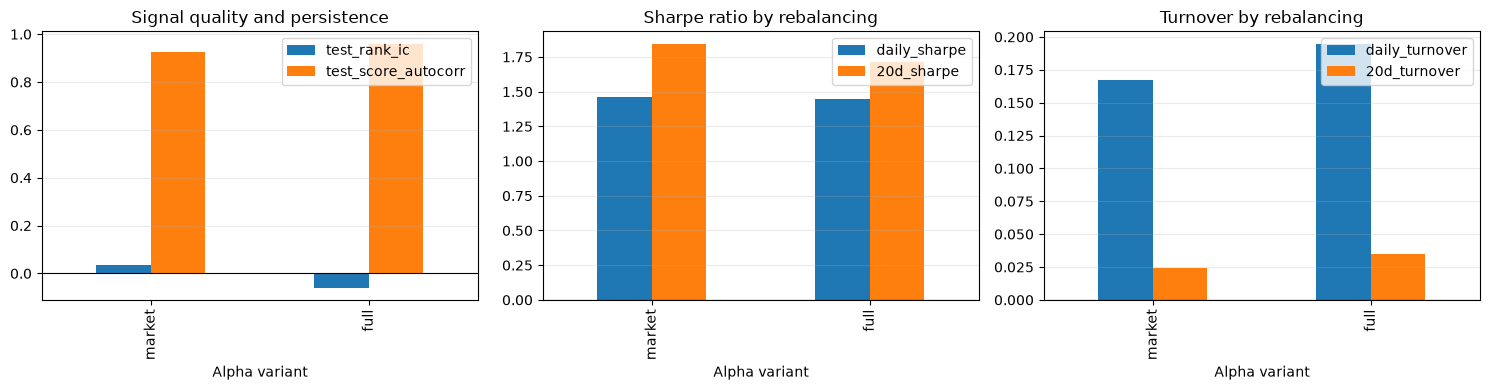

In [7]:
IMAGE_DIR = ROOT / "images"
IMAGE_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
summary[["test_rank_ic", "test_score_autocorr"]].plot.bar(ax=axes[0], title="Signal quality and persistence")
summary[["daily_sharpe", "20d_sharpe"]].plot.bar(ax=axes[1], title="Sharpe ratio by rebalancing")
summary[["daily_turnover", "20d_turnover"]].plot.bar(ax=axes[2], title="Turnover by rebalancing")
for axis in axes:
    axis.axhline(0.0, color="black", linewidth=0.8)
    axis.grid(axis="y", alpha=0.25)
    axis.set_xlabel("Alpha variant")
fig.tight_layout()
fig.savefig(IMAGE_DIR / "diagnostic_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
# print(f"PNG file saved: {IMAGE_DIR / 'diagnostic_comparison.png'}")

## Additional Checks: Time Robustness, Costs, and Feature Ablation

The following checks use the additional fields created by the updated evaluation code. They are kept separate from the main figures because the current stored report may not contain these fields yet. When they are present, the cells print a short interpretation together with the tables.

In [11]:
# 1. Time robustness
available_splits = sorted(comparison.get("alpha_quality", {}))
split_rank_ic = quality.pivot(index="split", columns="alpha", values="rank_ic_mean")
if {"market", "full"}.issubset(split_rank_ic.columns):
    split_rank_ic["full_minus_market"] = split_rank_ic["full"] - split_rank_ic["market"]
display(split_rank_ic)

# 2. Transaction-cost sensitivity
cost_sensitivity = comparison.get("cost_sensitivity", {})
if cost_sensitivity:
    cost_rows = []
    for split, models in cost_sensitivity.items():
        for alpha, costs in models.items():
            for cost_bps, rebalances in costs.items():
                for hold, metrics in rebalances.items():
                    cost_rows.append({"split": split, "alpha": alpha, "cost_bps": float(cost_bps), "hold": hold, **metrics})
    cost_table = pd.DataFrame(cost_rows).sort_values(["split", "alpha", "cost_bps", "hold"])
else:
    cost_table = pd.DataFrame([{"status": "not available in stored report"}])
display(cost_table)

# 3. Feature ablation
models = set(comparison.get("metadata", {}).get("models", []))
if "no_levels" in models:
    ablation = quality[quality["alpha"].isin(["market", "no_levels", "full"])]
    ablation_table = ablation.sort_values(["split", "alpha"])[["split", "alpha", "feature_set", "n_samples", "rank_ic_mean", "mse"]]
else:
    ablation_table = quality[quality["alpha"].isin(["market", "full"])]
    ablation_table = ablation_table.sort_values(["split", "alpha"])[["split", "alpha", "feature_set", "n_samples", "rank_ic_mean", "mse"]]
display(ablation_table)

# 4. Bootstrap results
bootstrap = comparison.get("bootstrap", {})
if bootstrap:
    bootstrap_rows = []
    for split, conditions in bootstrap.items():
        for hold, metrics in conditions.items():
            bootstrap_rows.append({"split": split, "hold": hold, **metrics})
    bootstrap_table = pd.DataFrame(bootstrap_rows).sort_values(["split", "hold"])
else:
    bootstrap_table = pd.DataFrame([{"status": "not available in stored report"}])
display(bootstrap_table)

alpha,full,market,no_levels,full_minus_market
split,,,,
test,-0.059649,0.036146,-0.113914,-0.095795


,split,alpha,cost_bps,hold,mean_reward,n_steps,action_share_sell,action_share_hold,action_share_buy,mean_log_return,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,mean_turnover,total_transaction_cost,equal_weight_mean_log_return,allow_short,rebalance_every
13,test,full,0.0,20d,0.001988,91,0.312088,0.467582,0.220330,0.001988,0.198297,0.650302,0.315936,1.741759,-0.183128,0.034827,0.000000,0.002594,0.0,20.0
12,test,full,0.0,daily,0.001840,91,0.312088,0.467582,0.220330,0.001840,0.182268,0.589890,0.322935,1.595906,-0.211269,0.194505,0.000000,0.002594,0.0,1.0
15,test,full,10.0,20d,0.001953,91,0.312088,0.467582,0.220330,0.001953,0.194504,0.635876,0.315542,1.715681,-0.184453,0.034827,3556.275436,0.002594,0.0,20.0
14,test,full,10.0,daily,0.001645,91,0.312088,0.467582,0.220330,0.001645,0.161522,0.513827,0.322284,1.446137,-0.213939,0.194505,20084.767545,0.002594,0.0,1.0
17,test,full,25.0,20d,0.001901,91,0.312088,0.467582,0.220330,0.001901,0.188831,0.614451,0.314992,1.676225,-0.186437,0.034827,8874.575428,0.002594,0.0,20.0
16,test,full,25.0,daily,0.001353,91,0.312088,0.467582,0.220330,0.001353,0.131071,0.406456,0.321351,1.220182,-0.217929,0.194505,49557.351072,0.002594,0.0,1.0
1,test,market,0.0,20d,0.002369,91,0.262637,0.606593,0.130769,0.002369,0.240540,0.816479,0.355284,1.857428,-0.221812,0.024310,0.000000,0.002594,0.0,20.0
0,test,market,0.0,daily,0.001947,91,0.262637,0.606593,0.130769,0.001947,0.193789,0.633165,0.347457,1.584496,-0.215479,0.167256,0.000000,0.002594,0.0,1.0
3,test,market,10.0,20d,0.002344,91,0.261538,0.607692,0.130769,0.002344,0.237798,0.805381,0.354788,1.842237,-0.222033,0.024310,2524.697295,0.002594,0.0,20.0
2,test,market,10.0,daily,0.001779,91,0.261538,0.607692,0.130769,0.001779,0.175753,0.565745,0.347437,1.463017,-0.217633,0.167256,16587.201344,0.002594,0.0,1.0


,split,alpha,feature_set,n_samples,rank_ic_mean,mse
1,test,full,with_fundamentals,1079.0,-0.059649,0.019879
0,test,market,market_only,1079.0,0.036146,0.021336
2,test,no_levels,fundamentals_no_levels,1079.0,-0.113914,0.020048


,split,hold,market_minus_full_mean_daily_return
1,test,20d,{'observed_mean_difference': 0.000440532942938...
0,test,daily,{'observed_mean_difference': 0.000165790794023...
